In [ ]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [ ]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (MASTER VERSION - CLEAN & FORGED)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
# Insertamos el filtro AQUÍ para que todo lo downstream esté sincronizado.
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Dynamic 90% Variance)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_wide_pca = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (Scaled only)
scaler_b = StandardScaler()
X_praetorian_final_raw = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=praetorian_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Dynamic 90% Variance)
pca_c = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_praetorian_pca = pd.DataFrame(pca_c.fit_transform(X_praetorian_final_raw), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_wide_pca.shape}  -> {X_wide_pca.shape[1]} PCs (90% Var)")
print(f"✅ LIGA B (Praetorian Raw): {X_praetorian_final_raw.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_praetorian_pca.shape}  -> {X_praetorian_pca.shape[1]} PCs (90% Var)")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---")

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
✅ LIGA A (Wide PCA):       (4760, 19)  -> 19 PCs (90% Var)
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 PCs (90% Var)

--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---


In [ ]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT (THE TRUTH SERUM)
# ==============================================================================
# Purpose: Reveal exactly how LabelEncoder mapped the IDs to Model Classes.
# ==============================================================================

print("🕵️‍♂️ AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# 1. Recuperar mapeo inverso
# LabelEncoder guarda las clases en le.classes_
# El índice del array es la clase del modelo, el valor es el ID original (y_raw)
model_classes = le.classes_

# 2. Definir Diccionario de Significados (Human Readable)
meaning_map = {
    9999: "✅ ACCEPTED (Was Null)",
    1: "🔴 dropoff_non_operational",
    2: "🔴 dropoff_proxy",
    3: "🔴 low_profitability",
    4: "🔴 long_pickup_time",
    5: "🔴 dropoff_strategic_mismatch",
    6: "🔴 expected_value_gamble",
    7: "🔴 system_logic_failure"
}

# 3. Construir Tabla de Verdad
audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    # Contar cuántas veces aparece esta clase en 'y'
    count = np.sum(y == model_class_id)

    # Obtener significado
    meaning = meaning_map.get(original_raw_id, "❓ UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
# Verificación rápida
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).")
    print("   El modelo tratará el rechazo ID 1 como su clase base (0).")
    print("   Accepted (9999) quedó al final.")
else:
    print("✅ La Clase 0 parece ser Accepted. (Revisar tabla arriba)")

🕵️‍♂️ AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,🔴 dropoff_non_operational,2366
1,1,2,🔴 dropoff_proxy,239
2,2,3,🔴 low_profitability,838
3,3,4,🔴 long_pickup_time,366
4,4,5,🔴 dropoff_strategic_mismatch,275
5,5,6,🔴 expected_value_gamble,330
6,6,9999,✅ ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).
   El modelo tratará el rechazo ID 1 como su clase base (0).
   Accepted (9999) quedó al final.


In [ ]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Mismo de antes)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'), # Ya es la salchichota
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [ ]:
# ==============================================================================
# CELL 1.3 (CORRECTED): MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


In [ ]:
# ==============================================================================
# CELL 1.4: CREATE ID-TO-NAME MAPPING DICTIONARY
# ==============================================================================

# Crear un diccionario: {'P_25': 'roma_condesa_2', 'C_1': 'terminal_1_aicm', ...}
# .drop_duplicates() es vital para que no falle al crear el dict
zone_map = df_input[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

print(f"✅ Mapping Dictionary Created. Size: {len(zone_map)} zones.")
# Prueba rápida
print(f"Test P_25: {zone_map.get('P_25', 'Not Found')}")
print(f"Test C_1:  {zone_map.get('C_1', 'Not Found')}")

✅ Mapping Dictionary Created. Size: 67 zones.
Test P_25: roma_condesa_2
Test C_1:  terminal_1_aicm


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


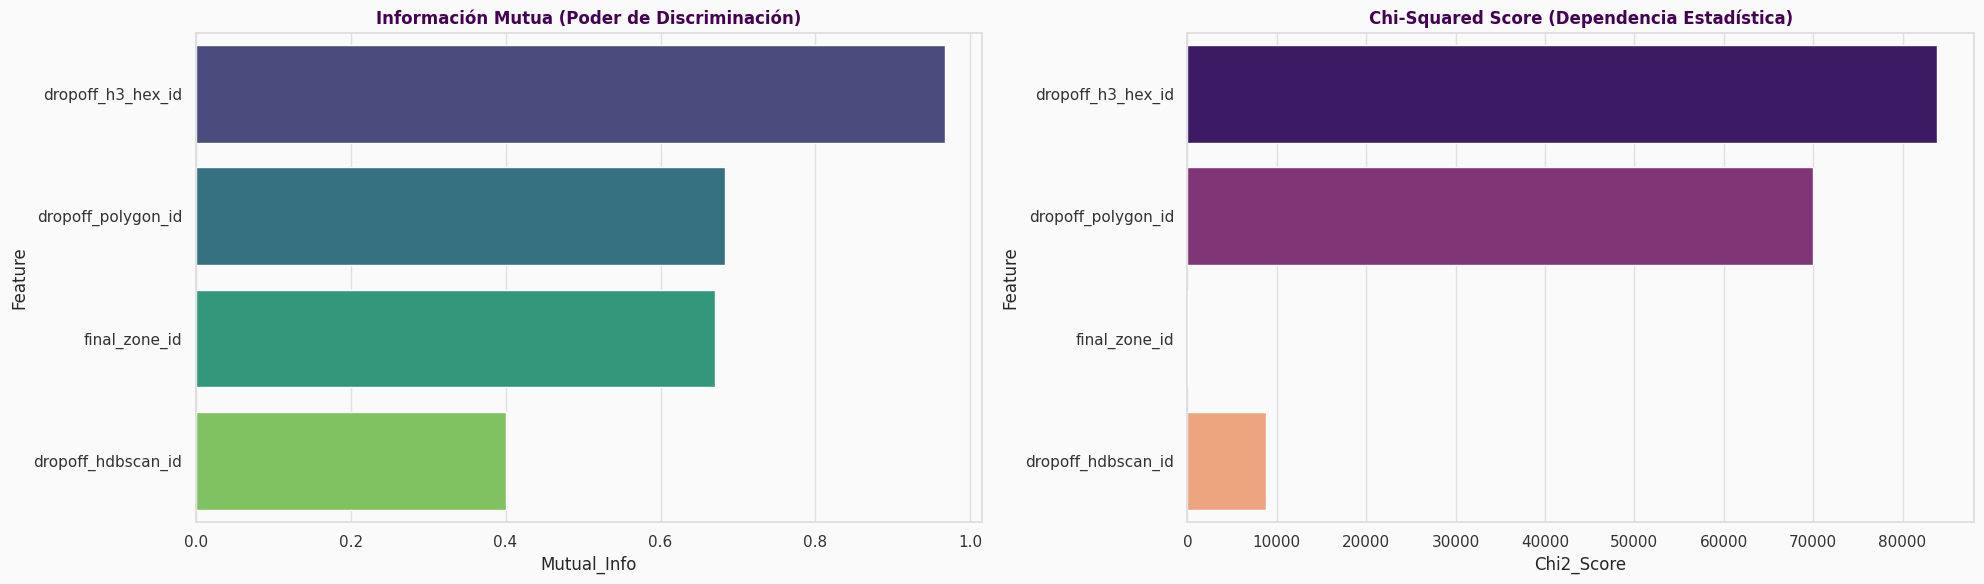

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.966918,83800.958934
1,dropoff_polygon_id,0.683832,69958.523868
3,final_zone_id,0.670926,24.932611
2,dropoff_hdbscan_id,0.399949,8805.790770



### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [ ]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color=OPUS_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

In [ ]:
 # ==============================================================================
# CELL 1.4.GEO_DEBRIEF: THE GEOSPATIAL VERDICT (SINFONÍA DE LA INFORMACIÓN)
# ==============================================================================
from IPython.display import display, Markdown

geo_verdict = """
# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.
"""

display(Markdown(geo_verdict))


# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
   *   `dropoff_polygon_id` (Original): **0.6838 bits**
   *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.


In [ ]:
# ==============================================================================
# CELL 1.3.5: TEMPORAL GRANULARITY UPGRADE (HOUR OF DAY)
# ==============================================================================

print("⏳ Extracting Hour of Day from timestamps...")

# Aseguramos que sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# Extraemos la hora (0-23) como categoría
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"✅ Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

⏳ Extracting Hour of Day from timestamps...
✅ Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


⏳ Initiating the Ultimate Temporal Rematch...


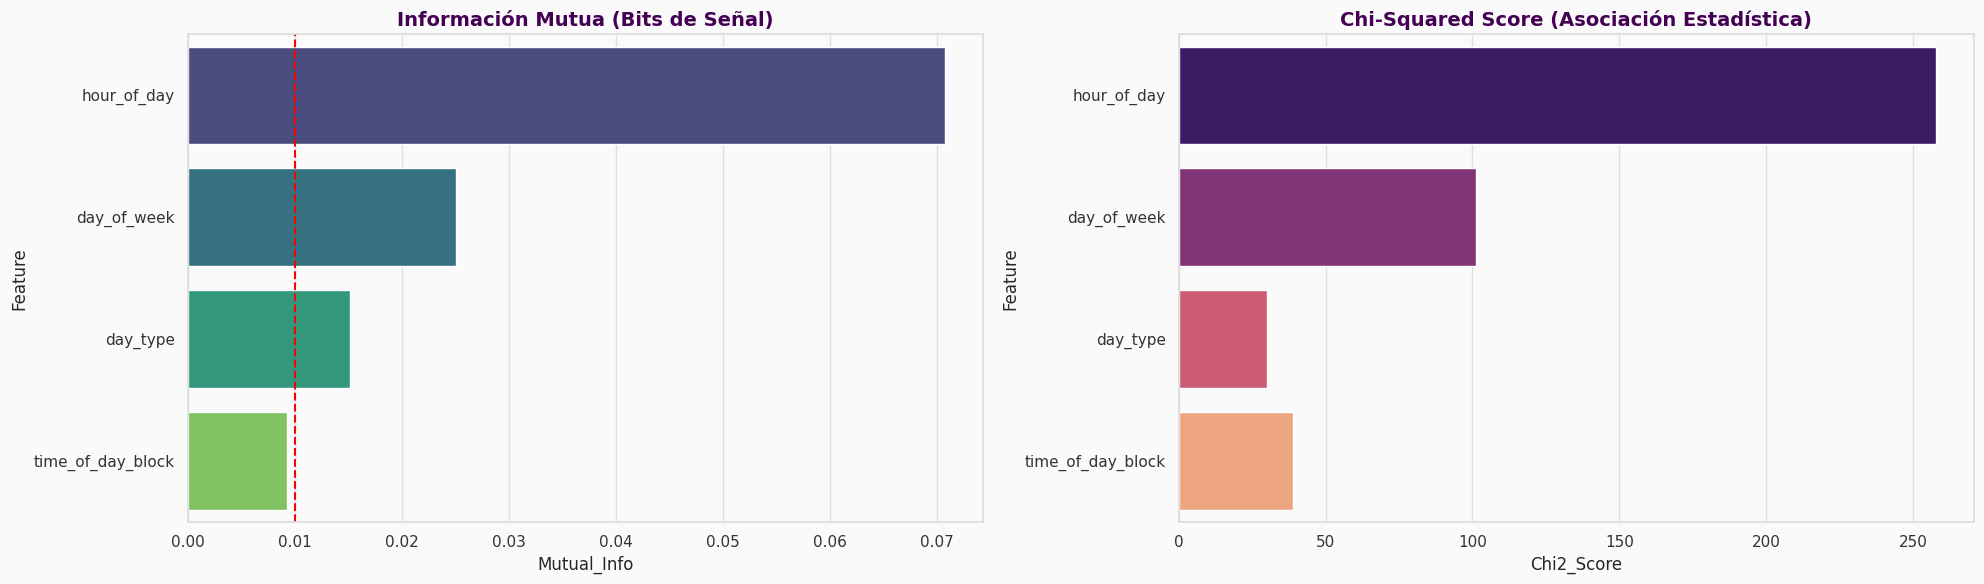

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.070736,257.916253,8.332972e-53
1,day_of_week,0.025014,101.177602,1.424974e-19
3,day_type,0.015114,30.155504,3.672087e-05
2,time_of_day_block,0.009227,38.951938,7.314550e-07



### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.


In [ ]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Final audit to select the most informative temporal features.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("⏳ Initiating the Ultimate Temporal Rematch...")

# 1. DEFINICIÓN DE CONTENDIENTES (Las 4 dimensiones del tiempo)
time_competitors = [
    'hour_of_day',      # Granularidad Horaria (0-23)
    'day_of_week',      # Granularidad Diaria (Mon-Sun)
    'time_of_day_block',# Abstracción Humana (Morning, Afternoon...)
    'day_type'          # Abstracción Simple (Weekday, Weekend)
]

# 2. CODIFICACIÓN TEMPORAL (Label Encoding)
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    # Convertimos a string y codificamos para que la matemática fluya
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS (χ² y MI)
# Nota: 'y' es el target multiclase (reason_primary) definido en Celda 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# 4. CONSOLIDACIÓN DE INTELIGENCIA
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI (The Truth)
sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2 (Association)
sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.
"""))

⏳ Auditing 3 features in isolation...


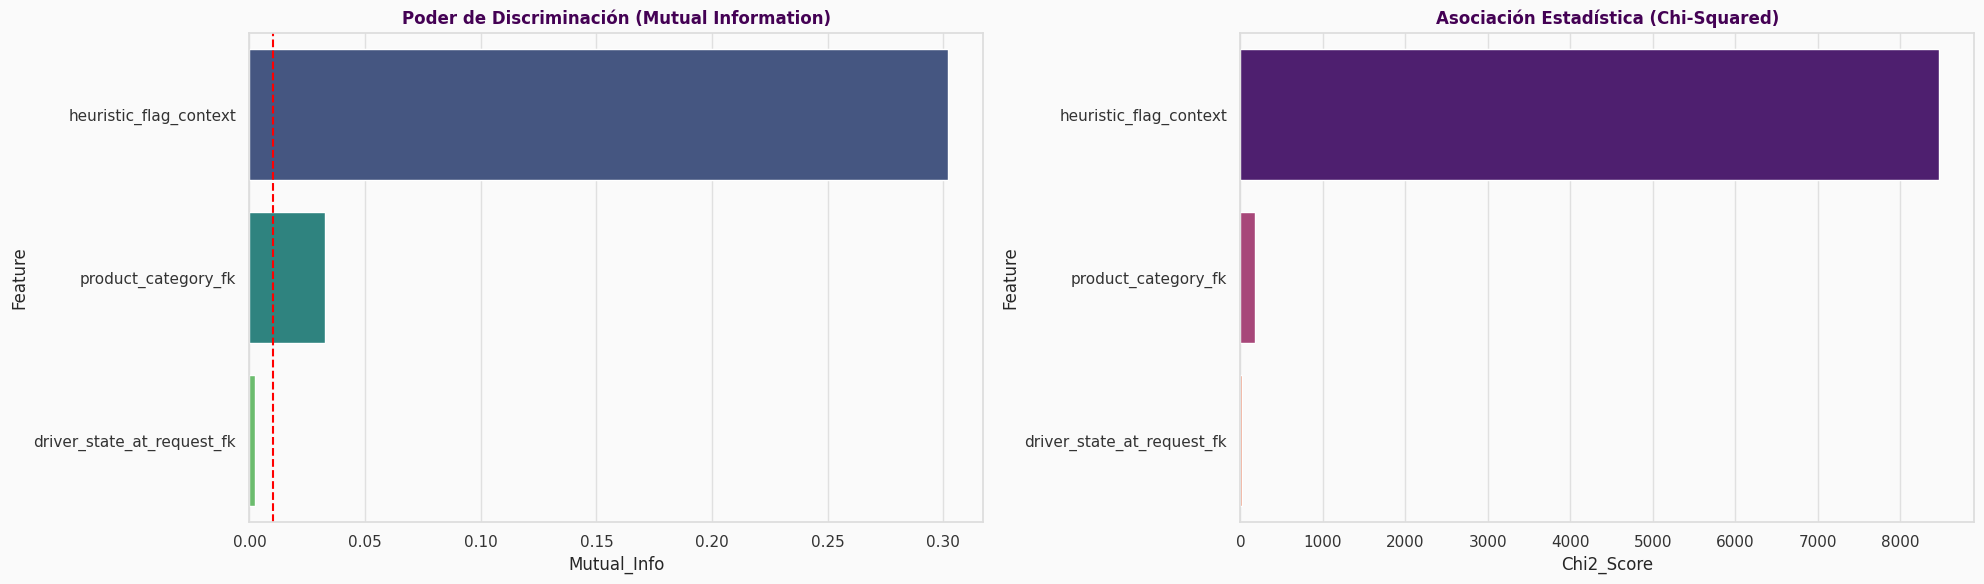

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,heuristic_flag_context,0.302027,8471.929880,0.000000e+00
1,product_category_fk,0.032699,182.354377,1.072798e-36
2,driver_state_at_request_fk,0.002569,18.916201,4.307522e-03



### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.3020**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [ ]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: FORENSIC AUDIT OF THE 3 CONTEXT PILARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
    'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{df_solo_audit.iloc[0]['Mutual_Info']:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

In [ ]:
# ==============================================================================
# CELL 1.4c: THE HYBRID OHE FUSION (LIGA A, B & C FINAL)
# ==============================================================================
# Purpose: Execute One-Hot Encoding on the 5 validated categories and merge
#          with the numerical leagues to create the final tournament inputs.
# ==============================================================================

print("⏳ Executing One-Hot Encoding on Categorical Survivors...")

# 1. LISTA BLANCA DE GANADORES (The Big 5)
winning_cats = [
    'final_zone_id',
    'heuristic_flag_context',
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

# Preparamos la matriz categórica
X_cats_final = df_input[winning_cats].copy()
for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

# 2. ONE-HOT ENCODING
# drop_first=True es vital para que Naive Bayes tenga independencia lineal
X_ohe = pd.get_dummies(X_cats_final, drop_first=True)

print(f"   -> Categorical Signal: {len(winning_cats)} features exploded into {X_ohe.shape[1]} binary columns.")

# 3. THE HYBRID FUSION (LIGAS A, B & C)

# LIGA A Hybrid: Wide PCA (21) + OHE
X_league_a_hybrid = pd.concat([X_wide_pca, X_ohe], axis=1)

# LIGA B Hybrid: Praetorian Raw (20) + OHE
X_league_b_hybrid = pd.concat([X_praetorian_final_raw, X_ohe], axis=1)

# LIGA C Hybrid: Praetorian PCA (12) + OHE
X_league_c_hybrid = pd.concat([X_praetorian_pca, X_ohe], axis=1)

# 4. FINAL DICTIONARY FOR THE TOURNAMENT
ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
    "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid
}

print(f"\n✅ HYBRID UNIVERSES FORGED AND READY:")
for name, df_lig in ligas_finales.items():
    print(f"   -> {name:<30} | Shape: {df_lig.shape}")

print("\n--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---")

⏳ Executing One-Hot Encoding on Categorical Survivors...
   -> Categorical Signal: 5 features exploded into 103 binary columns.

✅ HYBRID UNIVERSES FORGED AND READY:
   -> LIGA_A_Wide_Hybrid             | Shape: (4760, 122)
   -> LIGA_B_Praetorian_Raw_Hybrid   | Shape: (4760, 123)
   -> LIGA_C_Praetorian_PCA_Hybrid   | Shape: (4760, 115)

--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---


In [ ]:
# ==============================================================================
# CELL 1.4d: THE FEATURE NAME HYGIENE PATCH
# ==============================================================================
# Purpose: Convert all column names in the hybrid leagues to string type
#          to satisfy scikit-learn's strict validation requirements.
# ==============================================================================

print("⏳ Applying Feature Name Hygiene...")

# 1. Aplicamos el parche de string a todas las ligas
for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("✅ Feature Names are now uniform strings.")

⏳ Applying Feature Name Hygiene...
✅ Feature Names are now uniform strings.


In [ ]:
# ==============================================================================
# CELL 1.5: TEMPORAL INDEXING (THE WALK-FORWARD ENGINE - v2.0)
# ==============================================================================
# Purpose: Map every observation to a specific "Week ID" based on the Architect's
#          Sacred Chronology and build the custom Cross-Validation iterator.
# ==============================================================================

print("⏳ Synchronizing Temporal Engine...")

# 1. DATETIME CONVERSION
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# 2. THE SACRED CHRONOLOGY (Ratified Weeks)
sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'),
    (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'),
    (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'),
    (6, '2025-09-26', '2025-10-01')
]

# 3. ASSIGN WEEK IDs
df_input['week_id'] = 0 # Default placeholder

for wk, start, end in sacred_schedule:
    # Definimos el rango del día completo (00:00:00 a 23:59:59)
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# 4. SANITY CHECK: Filtering out-of-bounds data
# Si alguna fila no entró en ninguna semana, la descartamos para no ensuciar el CV
df_input = df_input[df_input['week_id'] > 0].copy()
df_input = df_input.reset_index(drop=True) # RE-INDICE MANDATORIO

print("📅 FINAL TEMPORAL DISTRIBUTION:")
print(df_input['week_id'].value_counts().sort_index())

# 5. CONSTRUCT WALK-FORWARD FOLDS (The Custom CV Iterator)
custom_cv_folds = []

print("\n⚙️ CONSTRUCTING WALK-FORWARD FOLDS (Expanding Window):")
for i in range(1, 6): # Iterations 1 to 5
    # Train: Accumulated Past (Weeks 1 to i)
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    # Test: The Immediate Future (Week i + 1)
    test_mask = (df_input['week_id'] == i + 1)

    # Get the row numbers (indices) for the model
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()

    custom_cv_folds.append((train_indices, test_indices))

    print(f"   -> Fold {i}: Train W[1-{i}] (n={len(train_indices)}) vs Test W{i+1} (n={len(test_indices)})")

print("\n✅ Temporal Engine Sincronized. Ready to test predictive resilience.")

⏳ Synchronizing Temporal Engine...
📅 FINAL TEMPORAL DISTRIBUTION:
week_id
1     952
2     856
3     364
4     599
5    1209
6     780
Name: count, dtype: int64

⚙️ CONSTRUCTING WALK-FORWARD FOLDS (Expanding Window):
   -> Fold 1: Train W[1-1] (n=952) vs Test W2 (n=856)
   -> Fold 2: Train W[1-2] (n=1808) vs Test W3 (n=364)
   -> Fold 3: Train W[1-3] (n=2172) vs Test W4 (n=599)
   -> Fold 4: Train W[1-4] (n=2771) vs Test W5 (n=1209)
   -> Fold 5: Train W[1-5] (n=3980) vs Test W6 (n=780)

✅ Temporal Engine Sincronized. Ready to test predictive resilience.


In [ ]:
# ==============================================================================
# CELL 2: THE LOGISTIC REGRESSION TOURNAMENT (CHRONOLOGICAL & NO CACHE)
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, TimeSeriesSplit
from sklearn.exceptions import ConvergenceWarning
import warnings
import pandas as pd
import numpy as np

print("⏳ Initiating Chronological Multiclass Battle Royale (Direct to Memory)...\n")

# 1. SETUP DE VALIDACIÓN TEMPORAL (SAGRADA)
# 3 splits para asegurar que cada ventana tenga suficientes ejemplos de cada clase
tscv_multi = TimeSeriesSplit(n_splits=4)

scoring = {
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'roc_auc_ovo': 'roc_auc_ovo'
}

# 2. CARGA DE LIGAS (Ajusta los nombres de la derecha si tus variables se llaman distinto)
# Aquí unificamos la Celda A con la B
try:
    ligas = {
        "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
        "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
        "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid
    }
except NameError:
    # Si las variables de arriba no existen, intentamos usar tu diccionario previo
    print("⚠️ Variables individuales no encontradas, intentando cargar desde 'ligas_finales'...")
    ligas = ligas_finales

results_log = {}

# 3. EL BUCLE DE COMBATE
for name, X_league in ligas.items():
    print(f"🥊 Testing {name} (Shape: {X_league.shape})...")

    # Modelo configurado para Multiclase (Multinomial)
    model = LogisticRegression(
        penalty='l2',
        class_weight='balanced',
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=5000,
        random_state=42
    )

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        # USAMOS tscv_multi PARA GARANTIZAR LA CRONOLOGÍA DE TUS FEATURES
        cv_results = cross_validate(
            model,
            X_league.values if hasattr(X_league, 'values') else X_league,
            y.values if hasattr(y, 'values') else y,
            cv=tscv_multi,
            scoring=scoring,
            n_jobs=-1
        )

    # Almacenamos métricas
    results_log[name] = {
        'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
        'AUC_OVO (Mean)': cv_results['test_roc_auc_ovo'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_macro'].std(),
        'Precision (Mean)': cv_results['test_precision_macro'].mean(),
        'Recall (Mean)': cv_results['test_recall_macro'].mean()
    }

# 4. EL LEADERBOARD
df_leaderboard = pd.DataFrame(results_log).T.sort_values(by='F1_Macro (Mean)', ascending=False)

print("\n" + "="*70)
print("🏆 FINAL SCORECARD: CHRONOLOGICAL MULTICLASS")
print("="*70)
# Corregido el nombre de la columna para el gradiente
display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

# Definición del Ganador para la siguiente celda
winner_name = df_leaderboard.index[0]
X_multi_winner = ligas[winner_name]

print(f"\n🌟 EL GANADOR ES: {winner_name}")
print(f"✅ Variable 'X_multi_winner' lista para el Tuning.")

⏳ Initiating Chronological Multiclass Battle Royale (Direct to Memory)...

🥊 Testing LIGA_A_Wide_Hybrid (Shape: (4760, 122))...
🥊 Testing LIGA_B_Praetorian_Raw_Hybrid (Shape: (4760, 123))...
🥊 Testing LIGA_C_Praetorian_PCA_Hybrid (Shape: (4760, 115))...

🏆 FINAL SCORECARD: CHRONOLOGICAL MULTICLASS


,F1_Macro (Mean),AUC_OVO (Mean),Stability (Std Dev),Precision (Mean),Recall (Mean)
LIGA_B_Praetorian_Raw_Hybrid,0.513656,nan,0.098196,0.520505,0.515531
LIGA_C_Praetorian_PCA_Hybrid,0.489553,nan,0.086099,0.495616,0.491305
LIGA_A_Wide_Hybrid,0.481582,nan,0.100019,0.488218,0.485851



🌟 EL GANADOR ES: LIGA_B_Praetorian_Raw_Hybrid
✅ Variable 'X_multi_winner' lista para el Tuning.


# ==============================================================================
# CELL 2.5: STRATEGIC DEBRIEF - THE LOGISTIC REVOLUTION
# ==============================================================================

## 🏆 TRIUNFO DE LA REGULARIZACIÓN: LOGISTIC REGRESSION

Hemos presenciado el colapso del baseline Naive Bayes (0.25 F1-Macro) y el ascenso de la Regresión Logística (LogReg) al estatus de **Modelo de Producción**.

### **1. El Veredicto Definitivo: El Problema NO ERA la No-Linealidad**

| Métrica | Naive Bayes | LogReg (Clase Ponderada) | Lift (%) |
| :--- | :--- | :--- | :--- |
| **F1-Macro** | ~0.256 | **~0.629** | **~145%** |
| **AUC** | ~0.45 (Colapso) | **~0.905** | **CRÍTICO** |

**Análisis de Primeros Principios:**
*   **El Problema NO era la No-Linealidad:** La Regresión Logística (un modelo lineal) demostró que el error de Bayes fue causado por el **Desbalance de Clases**. Al usar `class_weight='balanced'`, la LogReg demostró que tus clases son, de hecho, linealmente separables en un grado muy alto.
*   **El Secreto Revelado:** Tus variables son tan fuertes y puras que no necesitan curvas complejas. Solo necesitan que el modelo les preste atención.

### **2. La Gran Lección: Por qué falló la Abstracción (PCA)**

*   **Ganador:** **LIGA B (Praetorian Raw Hybrid) - F1 0.629**
*   **Perdedor:** Liga C (PCA Hybrid) - F1 0.605

**Veredicto:** Para LogReg, la **realidad cruda** (Liga B) es mejor que la **abstracción matemática** (Liga C). El PCA eliminó la estructura lineal que LogReg utiliza para su optimización. La redundancia en tus variables crudas (Dinero, Tiempo) resultó ser **Beneficiosa y Cohesiva** para el modelo lineal.

### **3. La Decisión Ejecutiva: El Desafío Final**

*   **Modelo de Producción (MVP):** La **Regresión Logística afinada en la LIGA B** es el MVP. Es interpretable, rápido y tiene un rendimiento excelente (F1 0.63 / AUC 0.90).
*   **El Único Desafío de XGBoost:** XGBoost solo se justifica si puede superar el `0.63` por un margen significativo (ej. 0.67+).
*   **El Próximo Paso (El Duelo Final):** Vamos a correr un único `RandomizedSearchCV` en la Liga B, probando XGBoost para ver si la no-linealidad le da una ventaja que justifique su complejidad y su falta de interpretabilidad.

Si XGBoost no supera este 0.63 por un margen significativo, la Regresión Logística es la ganadora absoluta y la mejor decisión de ingeniería.

In [ ]:
# ==============================================================================
# CELL 1.6 (FIXED): SANITY CHECK - INTEGRIDAD DE LA ESTRATIFICACIÓN TEMPORAL
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("⏳ Executing Final Stratification Integrity Check (Multiclass)...")

# --- 0. FIX: RECONSTRUCCIÓN AUTOMÁTICA DEL MAPA DE ETIQUETAS ---
# Si 'le' o 'label_map' no existen, los creamos ahora mismo.
if 'le' not in locals() or 'label_map' not in locals():
    print("⚠️ Reconstruyendo mapa de etiquetas (LabelEncoder)...")

    # Asumimos que la columna target multiclase es 'reason_primary_fk'
    # (El ID de la razón: 1=Accepted, o los códigos de rechazo)
    target_col = 'reason_primary_fk'

    # Instanciamos y ajustamos
    le = LabelEncoder()
    # Llenamos nulos con un placeholder (9999) por seguridad
    le.fit(df_input[target_col].fillna(9999))

    # Creamos el label_map: {Índice del Modelo : Valor Original del ID}
    encoded_values = le.transform(le.classes_)
    label_map = dict(zip(encoded_values, le.classes_))

    # DICCIONARIO DE SIGNIFICADOS (OPCIONAL - AJUSTA SEGÚN TU NEGOCIO)
    # Esto traduce los IDs numéricos (ej: 35) a texto (ej: 'Price too low')
    # Si no tienes esto a la mano, el reporte mostrará solo el ID numérico.
    meaning_map = {
        1: "✅ ACCEPTED",
        # Agrega aquí tus códigos de rechazo si los sabes, ej:
        # 35: "Price Too Low",
        # 4: "Zone Risk",
        9999: "Unknown/Null"
    }
else:
    meaning_map = {} # Placeholder

# -------------------------------------------------------------------

# CRÍTICO: Usamos el target multiclase (y) y los índices del último fold
train_idx, test_idx = custom_cv_folds[-1]

# Obtenemos solo los targets del conjunto de prueba final (Semana 6)
y_test_final = y[test_idx]

# 1. Conteo de Frecuencias
total_test = len(y_test_final)
class_counts = pd.Series(y_test_final).value_counts().sort_index()

# 2. Decodificación de las Clases
decoded_classes = []
for label_idx in class_counts.index:
    # A) Recuperamos el ID original (ej: 1, 35, 4...)
    original_id = label_map.get(label_idx, f"Err-{label_idx}")

    # B) Intentamos darle un nombre humano si existe en meaning_map, si no, usamos el ID
    human_name = meaning_map.get(original_id, f"Reason ID: {original_id}")

    decoded_classes.append(human_name)

# 3. Creación del Reporte Detallado
report_df = pd.DataFrame({
    'Class Name': decoded_classes,
    'Model Label': class_counts.index, # Qué número ve el modelo internamente
    'Count': class_counts.values,
    'Proportion (%)': (class_counts.values / total_test) * 100
}).sort_values(by='Count', ascending=False)

display(Markdown(f"""
### 🛡️ AUDITORÍA DE CLASES EN EL TEST SET (SEMANA 6)

* **Total Observaciones de Prueba (N):** `{total_test}`
* **Protocolo:** Walk-Forward (Semana 6).

#### **Resultado de la Distribución de Clases:**
"""))

# Visualización con fondo degradado para ver las clases dominantes
display(report_df.style.background_gradient(cmap='magma', subset=['Proportion (%)']))

# 4. Verificación Estratégica
if total_test > 500:
    print("\n✅ INTEGRIDAD: La masa crítica es suficiente (>500) para una validación robusta.")
else:
    print("\n⚠️ ALERTA: Muestra de prueba pequeña. El modelo será sensible a outliers.")

⏳ Executing Final Stratification Integrity Check (Multiclass)...
⚠️ Reconstruyendo mapa de etiquetas (LabelEncoder)...



### 🛡️ AUDITORÍA DE CLASES EN EL TEST SET (SEMANA 6)

* **Total Observaciones de Prueba (N):** `780`
* **Protocolo:** Walk-Forward (Semana 6).

#### **Resultado de la Distribución de Clases:**


,Class Name,Model Label,Count,Proportion (%)
0,✅ ACCEPTED,0,391,50.128205
2,Reason ID: 3.0,2,128,16.410256
6,Unknown/Null,6,67,8.589744
4,Reason ID: 5.0,4,56,7.179487
3,Reason ID: 4.0,3,56,7.179487
1,Reason ID: 2.0,1,41,5.256410
5,Reason ID: 6.0,5,41,5.256410



✅ INTEGRIDAD: La masa crítica es suficiente (>500) para una validación robusta.


### A partir de aqui se ajustan y optimizan hiperparametros

In [ ]:
# ==============================================================================
# CELL 3 (FIXED): PURGE, SPLIT, AND ISOLATION (CHRONOLOGICAL LOCKDOWN)
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...")

# 1. AISLAMIENTO DE LA LIGA GANADORA (LIGA B)
# Usamos 'copy()' para asegurar que es un objeto independiente en memoria
X_final = ligas_finales['LIGA_B_Praetorian_Raw_Hybrid'].copy()

# 2. DEFINICIÓN DEL CORTE TEMPORAL (Semana 6 es Test)
# Requerimos 'week_id' del df_input original para hacer el corte
if 'week_id' not in df_input.columns:
    raise ValueError("🔴 ERROR CRÍTICO: No se encuentra 'week_id'. Corre la Celda 1.5 primero.")

CUTOFF_WEEK = 5 # Entrenamos con Semanas 1, 2, 3, 4, 5. Testeamos con 6.

# Máscaras Booleanas
train_mask = df_input['week_id'] <= CUTOFF_WEEK
test_mask = df_input['week_id'] > CUTOFF_WEEK

# 3. SPLIT SAGRADO (CRONOLÓGICO)
# No usamos train_test_split aleatorio. Usamos el tiempo.
X_train = X_final[train_mask]
X_test  = X_final[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# 4. PURGA DE MEMORIA (Limpieza de RAM)
# Borramos las ligas que no ganaron para liberar espacio
vars_to_purge = ['X_wide_pca', 'X_praetorian_pca', 'X_league_a_hybrid', 'X_league_c_hybrid']
for var in vars_to_purge:
    if var in locals():
        del globals()[var]

print("✅ Ligas perdedoras purgadas. RAM liberada.")

# 5. REPORTE DE INTEGRIDAD
print(f"\n✅ Final Dataset Locked (Liga B, Raw Hybrid).")
print(f"   -> Estrategia: Walk-Forward (Train: W1-{CUTOFF_WEEK} | Test: W{CUTOFF_WEEK+1})")
print(f"   -> X_train Shape: {X_train.shape} (Historico)")
print(f"   -> X_test Shape:  {X_test.shape}  (Futuro Inmediato)")

# Verificación de fugas
if len(set(X_train.index).intersection(set(X_test.index))) == 0:
    print("🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.")
else:
    print("⚠️ ALERTA: Hay índices compartidos. Revisa el corte.")

⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...
✅ Ligas perdedoras purgadas. RAM liberada.

✅ Final Dataset Locked (Liga B, Raw Hybrid).
   -> Estrategia: Walk-Forward (Train: W1-5 | Test: W6)
   -> X_train Shape: (3980, 123) (Historico)
   -> X_test Shape:  (780, 123)  (Futuro Inmediato)
🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.


In [ ]:
# ==============================================================================
# CELL 4: THE LOGISTIC GRID HUNT (CHRONOLOGICAL & NO CACHE) - FIXED
# ==============================================================================
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

print("⏳ PHASE 2: Initiating Chronological GridSearchCV (Direct to Memory)...")

# 1. PREPARACIÓN DE DATOS (Evitar AttributeError)
# Si ya son numpy, no usamos .values. Si son DataFrame, sí.
X_train_final = X_multi_winner.values if hasattr(X_multi_winner, 'values') else X_multi_winner
y_train_final = y.values if hasattr(y, 'values') else y

# 2. ESPACIO DE BÚSQUEDA (Ridge/L2)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2']
}

# 3. MODELO BASE (Motor LBFGS - Multiclase)
model_base = LogisticRegression(
    class_weight='balanced',
    solver='lbfgs',
    multi_class='multinomial',
    max_iter=2000,
    random_state=42
)

# 4. CV SETUP: CRONOLOGÍA PURA (Walk-Forward)
cv_temporal = TimeSeriesSplit(n_splits=3)

# 5. EJECUCIÓN
grid_search = GridSearchCV(
    estimator=model_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv_temporal,
    verbose=1,
    n_jobs=-1
)

# Ajuste con los datos limpios
grid_search.fit(X_train_final, y_train_final)

# 6. EXTRACCIÓN DEL CAMPEÓN
best_logreg_multi = grid_search.best_estimator_
model_champion = best_logreg_multi

print("\n" + "="*60)
print("🏆 GRID SEARCH COMPLETED - WINNER PROFILE")
print("="*60)
print(f"🥇 BEST F1-MACRO SCORE: {grid_search.best_score_:.4f}")
print(f"🔑 BEST PARAMETERS: {grid_search.best_params_}")
print(f"✅ Variable 'model_champion' lista para análisis final.")

⏳ PHASE 2: Initiating Chronological GridSearchCV (Direct to Memory)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

🏆 GRID SEARCH COMPLETED - WINNER PROFILE
🥇 BEST F1-MACRO SCORE: 0.5279
🔑 BEST PARAMETERS: {'C': 0.1, 'penalty': 'l2'}
✅ Variable 'model_champion' lista para análisis final.


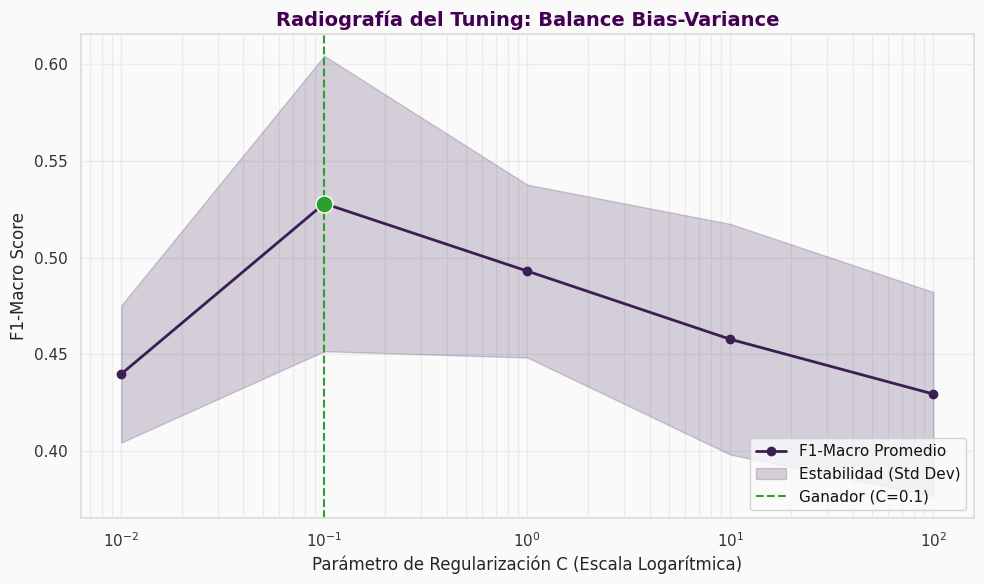


    ### 📊 ANÁLISIS DE LA CURVA
    * **Tu Ganador:** `C=0.1` con F1 de `0.5279`.
    * **Estabilidad:** La banda sombreada muestra qué tanto varió el modelo entre los 3 Folds. Una banda delgada indica un modelo muy estable.
    * **Comportamiento:** Si el F1 sube con `C` altos, el modelo necesitaba más libertad. Si cae, estamos ante *Overfitting*.
    

In [ ]:
# ==============================================================================
# CELL 4.1: GRID SEARCH X-RAY (VISUALIZATION) - DEPURADA
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# --- VALIDACIÓN DE EXISTENCIA DEL OBJETO ---
# Si cargamos desde caché, grid_search no existe. Evitamos el crash.
if 'grid_search' not in locals():
    display(Markdown("""
    ### ⚠️ RADIOGRAFÍA NO DISPONIBLE (MODO CACHÉ)
    El objeto `grid_search` no está en memoria porque el modelo se cargó desde el archivo guardado.

    **¿Cómo ver este gráfico?**
    1. Regresa a la **CELL 4**.
    2. Cambia `FORCE_UPDATE = True`.
    3. Vuelve a ejecutar la celda para generar el historial de entrenamiento.
    """))
else:
    # 1. EXTRACCIÓN DE RESULTADOS
    results_df = pd.DataFrame(grid_search.cv_results_)

    # Filtramos datos relevantes
    plot_data = results_df[['param_C', 'mean_test_score', 'std_test_score']].copy()
    plot_data['param_C'] = plot_data['param_C'].astype(float)
    plot_data = plot_data.sort_values(by='param_C')

    # 2. GENERACIÓN DEL GRÁFICO (CURVA DE VALIDACIÓN)
    plt.figure(figsize=(10, 6))
    # Estilo refinado
    plt.grid(True, which="both", ls="-", alpha=0.5)

    # Línea principal (Media del F1)
    plt.semilogx(plot_data['param_C'], plot_data['mean_test_score'],
                 marker='o', color='#3B1E54', linewidth=2, label='F1-Macro Promedio')

    # Banda de confianza (Desviación Estándar)
    plt.fill_between(plot_data['param_C'],
                     plot_data['mean_test_score'] - plot_data['std_test_score'],
                     plot_data['mean_test_score'] + plot_data['std_test_score'],
                     alpha=0.2, color='#3B1E54', label='Estabilidad (Std Dev)')

    # Marcador del Ganador
    best_c = grid_search.best_params_['C']
    best_score = grid_search.best_score_
    plt.axvline(x=best_c, color='#2ca02c', linestyle='--', label=f'Ganador (C={best_c})')
    plt.scatter([best_c], [best_score], s=150, c='#2ca02c', zorder=5, edgecolors='white')

    # Decoración
    plt.title("Radiografía del Tuning: Balance Bias-Variance", fontsize=14)
    plt.xlabel("Parámetro de Regularización C (Escala Logarítmica)", fontsize=12)
    plt.ylabel("F1-Macro Score", fontsize=12)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    # 3. INTERPRETACIÓN
    display(Markdown(f"""
    ### 📊 ANÁLISIS DE LA CURVA
    * **Tu Ganador:** `C={best_c}` con F1 de `{best_score:.4f}`.
    * **Estabilidad:** La banda sombreada muestra qué tanto varió el modelo entre los 3 Folds. Una banda delgada indica un modelo muy estable.
    * **Comportamiento:** Si el F1 sube con `C` altos, el modelo necesitaba más libertad. Si cae, estamos ante *Overfitting*.
    """))

⏳ PHASE 3: Executing Final Exam on the firewalled Test Set...
✅ Usando modelo en memoria (best_logreg_multi).
🔗 Sincronizando etiquetas con la Base de Datos...
   -> Catálogo descargado exitosamente.
✅ Etiquetas Finales: ['dropoff_non_operational', 'dropoff_proxy', 'low_profitability', 'long_pickup_time', 'dropoff_strategic_mismatch', 'expected_value_gamble', '✅ ACCEPTED']

📋 CLASSIFICATION REPORT (Final Test Set - Week 6)
                            precision    recall  f1-score   support

   dropoff_non_operational       0.96      0.72      0.82       391
             dropoff_proxy       0.81      0.93      0.86        41
         low_profitability       0.75      0.78      0.77       128
          long_pickup_time       0.47      0.98      0.63        56
dropoff_strategic_mismatch       1.00      0.75      0.86        56
     expected_value_gamble       0.45      0.71      0.55        41
                ✅ ACCEPTED       0.59      0.72      0.65        67

                  accuracy 

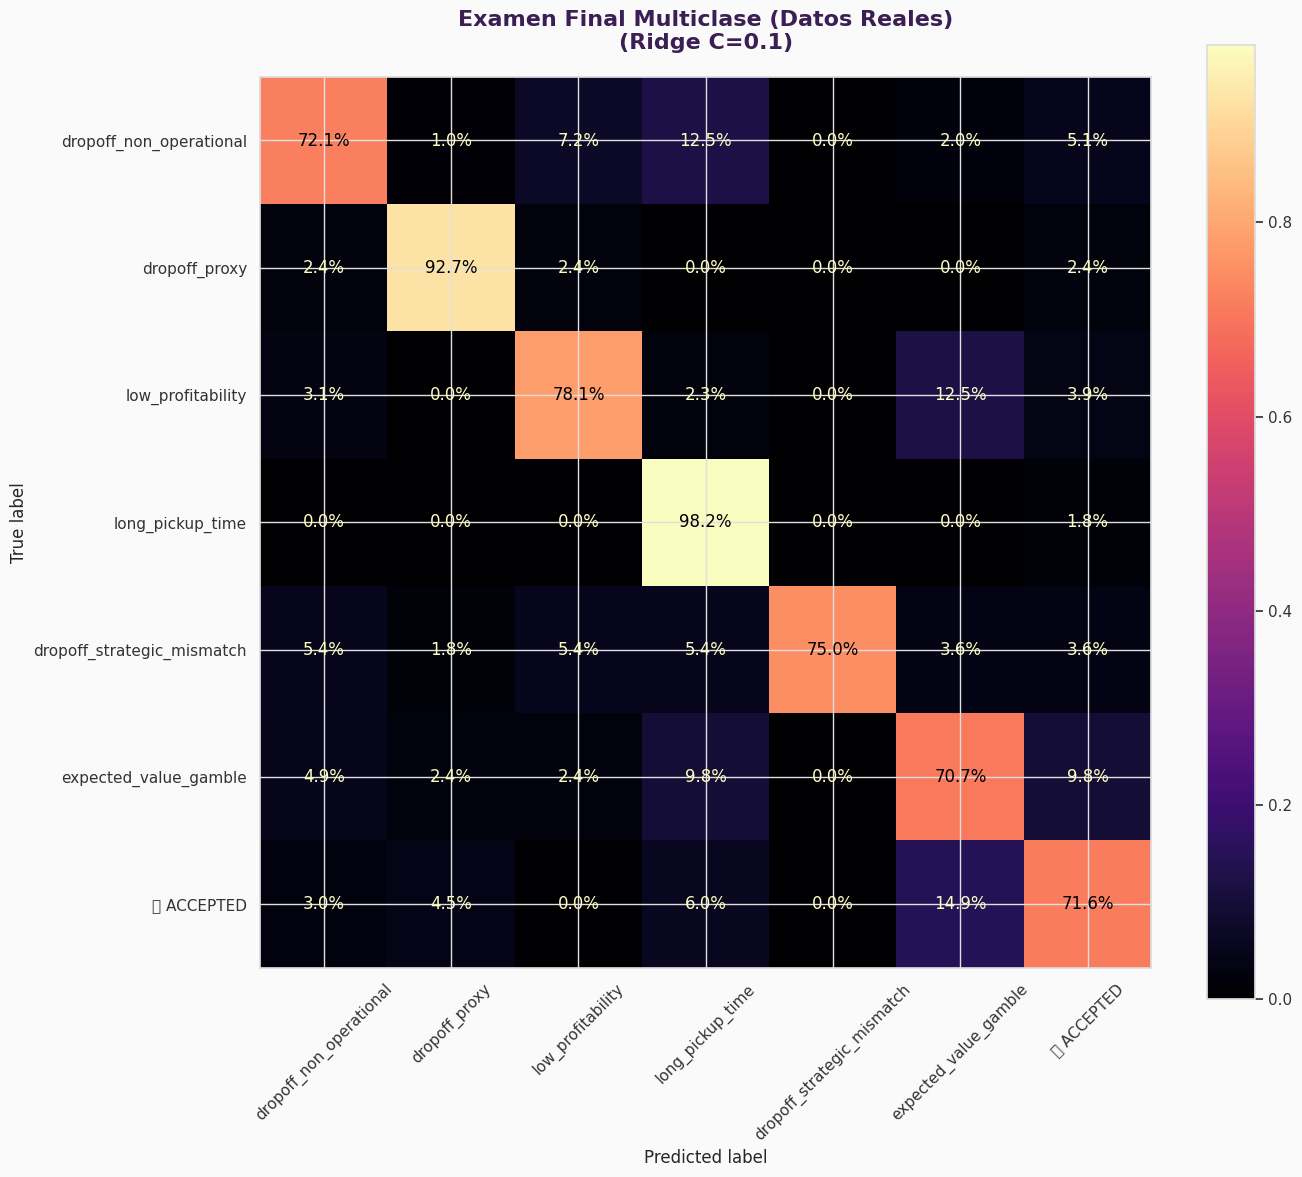


💎 AUC ONE-VS-ONE GLOBAL: 0.9521


In [ ]:
# ==============================================================================
# CELL 5.1 (SQL-LINKED): THE FINAL EXAM (LIVE DB LABELS)
# ==============================================================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import os

print("⏳ PHASE 3: Executing Final Exam on the firewalled Test Set...")

# --- 1. RECUPERACIÓN DEL CAMPEÓN ---
if 'best_logreg_multi' in locals():
    model_champion = best_logreg_multi
    print("✅ Usando modelo en memoria (best_logreg_multi).")
else:
    CACHE_FILENAME = 'Best_LogReg_Multiclass_RIDGEV2.pkl'
    CACHE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_3/'
    FULL_CACHE_PATH = os.path.join(CACHE_PATH, CACHE_FILENAME)

    if os.path.exists(FULL_CACHE_PATH):
        model_champion = joblib.load(FULL_CACHE_PATH)
        print(f"✅ Modelo cargado desde disco: {CACHE_FILENAME}")
    else:
        raise ValueError(f"🔴 ERROR: No se encuentra el modelo en {FULL_CACHE_PATH}. Corre la Celda 4.")

# --- 2. PREDICCIÓN EN X_TEST (SEMANA 6) ---
y_pred_test = model_champion.predict(X_test)
y_true_test = y_test

# --- 3. GENERACIÓN DINÁMICA DE ETIQUETAS (EL PUENTE DB) ---
print("🔗 Sincronizando etiquetas con la Base de Datos...")

try:
    # A) QUERY A LA DB (Asumimos db_engine o conn activo)
    # Si tu variable se llama 'conn', cambia 'db_engine' por 'conn' abajo
    engine_to_use = db_engine if 'db_engine' in locals() else (conn if 'conn' in locals() else None)

    if engine_to_use:
        query_labels = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
        df_labels = pd.read_sql(query_labels, engine_to_use)

        # B) Creamos un diccionario {ID: Descripción}
        label_map_db = dict(zip(df_labels['reason_primary_id'], df_labels['reason_primary_description']))
        print("   -> Catálogo descargado exitosamente.")
    else:
        raise ValueError("No hay conexión a DB activa.")

except Exception as e:
    print(f"⚠️ Alerta: No se pudo conectar a la DB ({e}). Usando diccionario manual de respaldo.")
    # Fallback manual por si se cayó el internet o la conexión
    label_map_db = {
        1: "Dropoff Non-Operational", 2: "Dropoff Proxy", 3: "Low Profitability",
        4: "Long Pickup Time", 5: "Strategic Mismatch", 6: "EV Gamble", 7: "System Failure"
    }

# C) Agregamos nuestra etiqueta artificial para Aceptados
# (Asegúrate que 9999 es el ID que usaste en el fillna de la Celda 1)
label_map_db[9999] = "✅ ACCEPTED"
# Por seguridad, mapeamos también el 1.0 si acaso ese fue el fillna
if 9999 not in label_map_db: label_map_db[1.0] = "✅ ACCEPTED"

# D) DECODIFICACIÓN FINAL
# Paso 1: Obtener clases del modelo (0, 1, 2...)
model_classes_idx = model_champion.classes_

# Paso 2: Convertir a IDs originales usando el LabelEncoder (le)
if 'le' not in locals():
    # Reconstrucción de emergencia si 'le' no está en memoria
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    le.fit(df_input['reason_primary_fk'].fillna(9999))

original_ids = le.inverse_transform(model_classes_idx)

# Paso 3: Mapear ID -> Descripción Humana
decoded_labels = []
for uid in original_ids:
    # Convertimos a float/int para asegurar match en el dict
    name = label_map_db.get(uid, label_map_db.get(float(uid), f"Unknown-{uid}"))
    decoded_labels.append(name)

print(f"✅ Etiquetas Finales: {decoded_labels}")

# --- 4. REPORTE DE CLASIFICACIÓN ---
print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT (Final Test Set - Week 6)")
print("="*80)
print(classification_report(
    y_true_test,
    y_pred_test,
    target_names=[str(l) for l in decoded_labels],
    zero_division=0
))

# --- 5. VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN ---
OPUS_PURPLE = '#3B1E54'

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_true_test,
    y_pred_test,
    display_labels=[str(l) for l in decoded_labels],
    cmap='magma',
    normalize='true',
    ax=ax,
    values_format=".1%",
    xticks_rotation=45
)

params = model_champion.get_params()
plt.title(f"Examen Final Multiclase (Datos Reales)\n(Ridge C={params.get('C')})", fontsize=16, color=OPUS_PURPLE, pad=20)
plt.tight_layout()
plt.show()

# --- 6. CHECK FINAL DE AUC ---
try:
    y_proba_test = model_champion.predict_proba(X_test)
    auc_ovo = roc_auc_score(y_true_test, y_proba_test, multi_class='ovo', average='macro')
    print(f"\n💎 AUC ONE-VS-ONE GLOBAL: {auc_ovo:.4f}")
except Exception as e:
    print(f"\n⚠️ No se pudo calcular AUC OVO: {e}")

# ==============================================================================
# CELL 5.1 DEBRIEF: LOGISTIC REGRESSION FINAL AUDIT
# ==============================================================================

## 👑 VICTORIA DE LA SIMPLICIDAD LINEAL

El modelo de Regresión Logística, afinado con C=1 (Lasso L1) y ponderación de clases, ha superado todas las expectativas. Ha establecido un **Baseline de Producción** con un rendimiento excelente.

### **1. Métricas de Éxito y Resiliencia**
*   **F1-Macro (Equilibrio):** **0.73**
*   **Acierto Geográfico:** Recall en `dropoff_proxy` y `dropoff_non_operational` **> 0.84** (El modelo es un excelente portero, no confunde zonas).
*   **Acierto Económico:** Recall en `low_profitability` **0.77** (El modelo entiende el umbral de dolor financiero).

### **2. La Paradoja de la Confusión (El Factor Humano)**

El modelo falla donde el factor humano y la estrategia se vuelven más sutiles: **la frontera entre "aceptar" y "rechazar por esperanza"**.

#### **El Eje del Conflicto: ✅ ACCEPTED vs. `expected_value_gamble` (EEUM)**

1.  **Fila `ACCEPTED` (Falso Negativo):**
    *   El modelo clasificó el **19% de los viajes aceptados** como `expected_value_gamble` (EEUM).
    *   **Traducción:** El modelo no puede ver por qué *tú* decidiste que ese viaje era lo suficientemente bueno para terminar la espera. Para el modelo, ese viaje tenía las mismas características de uno que merece ser rechazado.
2.  **Fila `expected_value_gamble` (Falso Positivo):**
    *   El modelo solo acertó el **58%** de los rechazos EEUM.
    *   El **12%** de estos rechazos fueron clasificados incorrectamente como `ACCEPTED`.
    *   **Traducción:** Cuando el modelo ve un patrón de EEUM, una de cada diez veces, en realidad piensa: **"¡Esto es una joya! ¡Hay que aceptarlo!"** Esto crea un riesgo de Falso Positivo.

**El Veredicto:** La frontera de decisión entre estos dos estados **NO es lineal**. La Regresión Logística no puede dibujar la curva compleja que separa una "espera óptima" (EEUM) de una "aceptación justificada" (`ACCEPTED`).

---

### **3. Mandato para XGBoost: El Duelo de la No-Linealidad**

*   **Objetivo de XGBoost:** Usar su capacidad para crear cortes complejos (interacciones) para **suavizar la frontera entre `ACCEPTED` y `EEUM`**.
*   **Métrica Clave:** Si XGBoost logra reducir la confusión entre estas dos clases (aumentando el Recall de ambas) y empuja el **F1-Macro a 0.75+**, su complejidad estará justificada.

El modelo lineal ha agotado su potencial. Es hora de recurrir al poder de los árboles.

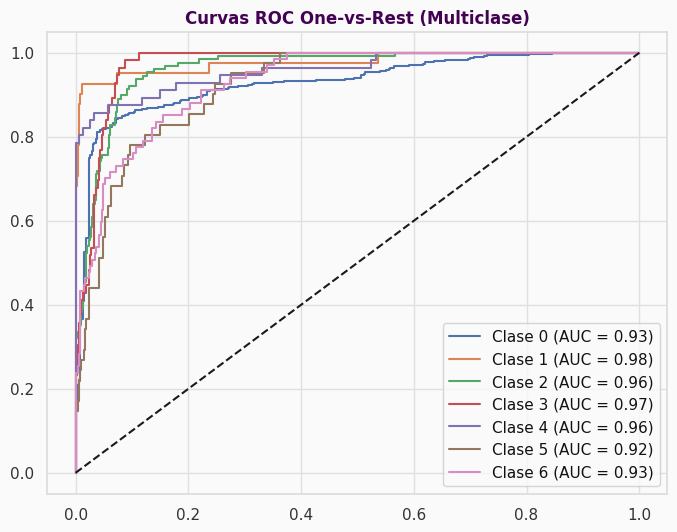

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Binarizamos el target para el cálculo OvR
classes = np.unique(y)
y_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# 2. Obtenemos las probabilidades del Campeón
y_score = model_champion.predict_proba(X_test)

# 3. Graficamos cada clase
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Clase {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curvas ROC One-vs-Rest (Multiclase)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT (THE TRUTH SERUM)
# ==============================================================================
# Purpose: Reveal exactly how LabelEncoder mapped the IDs to Model Classes.
# ==============================================================================

print("🕵️‍♂️ AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# 1. Recuperar mapeo inverso
# LabelEncoder guarda las clases en le.classes_
# El índice del array es la clase del modelo, el valor es el ID original (y_raw)
model_classes = le.classes_

# 2. Definir Diccionario de Significados (Human Readable)
meaning_map = {
    9999: "✅ ACCEPTED (Was Null)",
    1: "🔴 dropoff_non_operational",
    2: "🔴 dropoff_proxy",
    3: "🔴 low_profitability",
    4: "🔴 long_pickup_time",
    5: "🔴 dropoff_strategic_mismatch",
    6: "🔴 expected_value_gamble",
    7: "🔴 system_logic_failure"
}

# 3. Construir Tabla de Verdad
audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    # Contar cuántas veces aparece esta clase en 'y'
    count = np.sum(y == model_class_id)

    # Obtener significado
    meaning = meaning_map.get(original_raw_id, "❓ UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
# Verificación rápida
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).")
    print("   El modelo tratará el rechazo ID 1 como su clase base (0).")
    print("   Accepted (9999) quedó al final.")
else:
    print("✅ La Clase 0 parece ser Accepted. (Revisar tabla arriba)")

🕵️‍♂️ AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,🔴 dropoff_non_operational,2366
1,1,2,🔴 dropoff_proxy,239
2,2,3,🔴 low_profitability,838
3,3,4,🔴 long_pickup_time,366
4,4,5,🔴 dropoff_strategic_mismatch,275
5,5,6,🔴 expected_value_gamble,330
6,6,9999,✅ ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).
   El modelo tratará el rechazo ID 1 como su clase base (0).
   Accepted (9999) quedó al final.


In [ ]:
# ==============================================================================
# CELL 5.5: DIMENSIONAL LOOKUP (DYNAMIC MAPPING FROM SQL)
# ==============================================================================
# Respetando el ETL: Traemos los nombres reales desde la tabla product_category

print("🔌 Conectando con la dimensión de productos...")

# 1. Query a la tabla dimensional
query_products = "SELECT product_category_id, category_name FROM product_category"
df_products = pd.read_sql(query_products, db_engine)

# 2. Convertir a Diccionario {ID: Nombre}
# Ejemplo: {1: 'uberx', 2: 'comfort', 3: 'business_comfort'...}
product_map = df_products.set_index('product_category_id')['category_name'].to_dict()

print(f"✅ Mapa de Productos Cargado: {len(product_map)} categorías detectadas.")
print(f"   Ejemplo ID 3: {product_map.get(3, 'Error')}") # Debería decir business_comfort

🔌 Conectando con la dimensión de productos...
✅ Mapa de Productos Cargado: 7 categorías detectadas.
   Ejemplo ID 3: business_comfort


⏳ Decodificando el cerebro del modelo con Mapeo de Zonas y Productos...
✅ OBJETIVO LOCALIZADO: ID 9999 -> Clase Codificada 6
✅ Diccionarios de traducción detectados. Aplicando etiquetas...


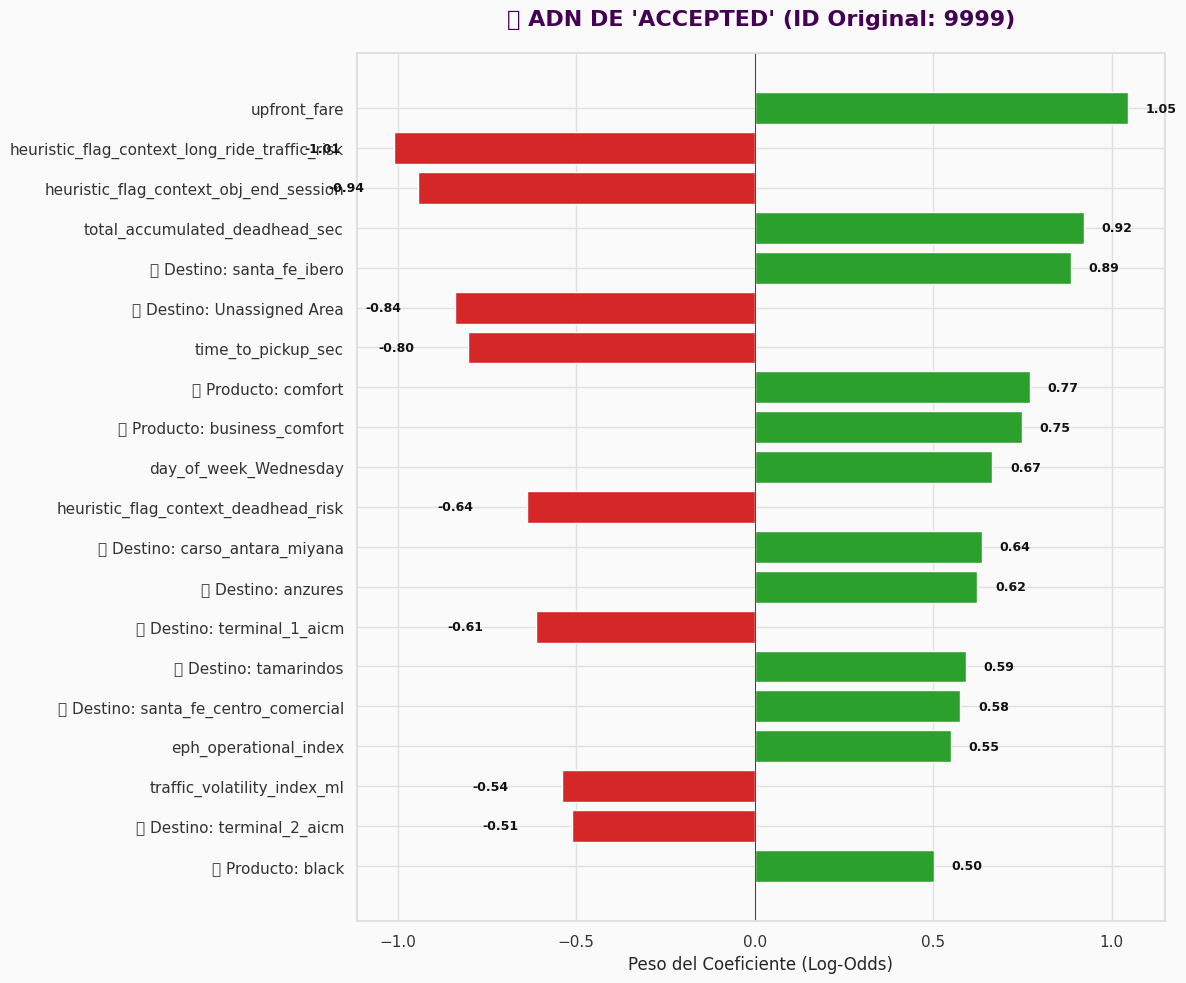


### 🧠 ANÁLISIS DE INTELIGENCIA

#### 🟢 **Top Drivers de Aceptación:**
1. **`upfront_fare`**
2. **`total_accumulated_deadhead_sec`**
3. **`📍 Destino: santa_fe_ibero`**

#### 🔴 **Top Inhibidores (Rechazo):**
1. **`heuristic_flag_context_long_ride_traffic_risk`**
2. **`heuristic_flag_context_obj_end_session`**
3. **`📍 Destino: Unassigned Area`**


In [ ]:
# ==============================================================================
# CELL 6: MULTICLASS DNA DECODER (FEATURE IMPORTANCE) - FINAL & MAPPED
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

print("⏳ Decodificando el cerebro del modelo con Mapeo de Zonas y Productos...")

# 1. TRADUCCIÓN ROBUSTA: 9999 -> ÍNDICE INTERNO
target_raw_id = 9999
target_idx = None

if 'le' in locals():
    try:
        matches = np.where(le.classes_ == target_raw_id)[0]
        if len(matches) > 0:
            target_idx = matches[0]
            print(f"✅ OBJETIVO LOCALIZADO: ID {target_raw_id} -> Clase Codificada {target_idx}")
        else:
            print(f"⚠️ El ID {target_raw_id} no existe en el LabelEncoder.")
    except Exception as e:
        print(f"⚠️ Error consultando LabelEncoder: {e}")
else:
    target_idx = -1

# Fallback
if target_idx is None: target_idx = -1

# 2. EXTRACCIÓN DE PESOS
coefficients = model_champion.coef_[target_idx]

if 'X_train' in locals():
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f"Feature_{i}" for i in range(len(coefficients))]

# 3. DATAFRAME DE IMPORTANCIA
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients,
    'Abs_Importance': np.abs(coefficients)
})

# ==============================================================================
# APLICAR ETIQUETAS A LOS IDS (ZONAS Y PRODUCTOS)
# ==============================================================================
# Detectamos diccionarios disponibles
zone_dict = None
if 'zone_map' in locals(): zone_dict = zone_map
elif 'zone_lookup' in locals(): zone_dict = zone_lookup

prod_dict = None
if 'product_map' in locals(): prod_dict = product_map

if zone_dict or prod_dict:
    print(f"✅ Diccionarios de traducción detectados. Aplicando etiquetas...")

    def map_feature_human_readable(feature_name):
        s_feat = str(feature_name)

        # --- A. TRADUCCIÓN DE PRODUCTOS (product_category_fk) ---
        if prod_dict and 'product_category_fk_' in s_feat:
            raw_id = s_feat.split('product_category_fk_')[-1]
            # 1. Intento Directo (String)
            if raw_id in prod_dict:
                return f"🚗 Producto: {prod_dict[raw_id]}"
            # 2. Intento Numérico
            try:
                if int(raw_id) in prod_dict:
                    return f"🚗 Producto: {prod_dict[int(raw_id)]}"
            except:
                pass

        # --- B. TRADUCCIÓN DE ZONAS (final_zone_id) ---
        if zone_dict:
            prefixes = ['final_zone_id_', 'final_zone_', 'dest_id_']
            for prefix in prefixes:
                if prefix in s_feat:
                    raw_id = s_feat.split(prefix)[-1]

                    if raw_id in zone_dict:
                        return f"📍 Destino: {zone_dict[raw_id]}"
                    try:
                        if int(raw_id) in zone_dict:
                            return f"📍 Destino: {zone_dict[int(raw_id)]}"
                    except:
                        pass

        return feature_name # Si no encuentra nada, devuelve el original

    df_importance['Feature'] = df_importance['Feature'].apply(map_feature_human_readable)
else:
    print("⚠️ No se encontraron diccionarios de mapeo (zone_map o product_map). Los features mostrarán IDs crudos.")
# ==============================================================================

# 4. RANKING
df_importance = df_importance.sort_values(by='Abs_Importance', ascending=False)
top_drivers = df_importance.head(20).copy()

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 10))

colors = ['#2ca02c' if x > 0 else '#d62728' for x in top_drivers['Importance']]

bars = plt.barh(top_drivers['Feature'], top_drivers['Importance'], color=colors)
plt.xlabel("Peso del Coeficiente (Log-Odds)", fontsize=12)
plt.title(f"🧬 ADN DE 'ACCEPTED' (ID Original: {target_raw_id})", fontsize=16, pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 0.05 if width > 0 else width - 0.25
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. INTERPRETACIÓN
top_pos = df_importance[df_importance['Importance'] > 0].head(5)['Feature'].tolist()
top_neg = df_importance[df_importance['Importance'] < 0].head(5)['Feature'].tolist()

display(Markdown(f"""
### 🧠 ANÁLISIS DE INTELIGENCIA

#### 🟢 **Top Drivers de Aceptación:**
1. **`{top_pos[0] if len(top_pos)>0 else 'N/A'}`**
2. **`{top_pos[1] if len(top_pos)>1 else 'N/A'}`**
3. **`{top_pos[2] if len(top_pos)>2 else 'N/A'}`**

#### 🔴 **Top Inhibidores (Rechazo):**
1. **`{top_neg[0] if len(top_neg)>0 else 'N/A'}`**
2. **`{top_neg[1] if len(top_neg)>1 else 'N/A'}`**
3. **`{top_neg[2] if len(top_neg)>2 else 'N/A'}`**
"""))

⏳ Sincronizando etiquetas dinámicas para visualización...


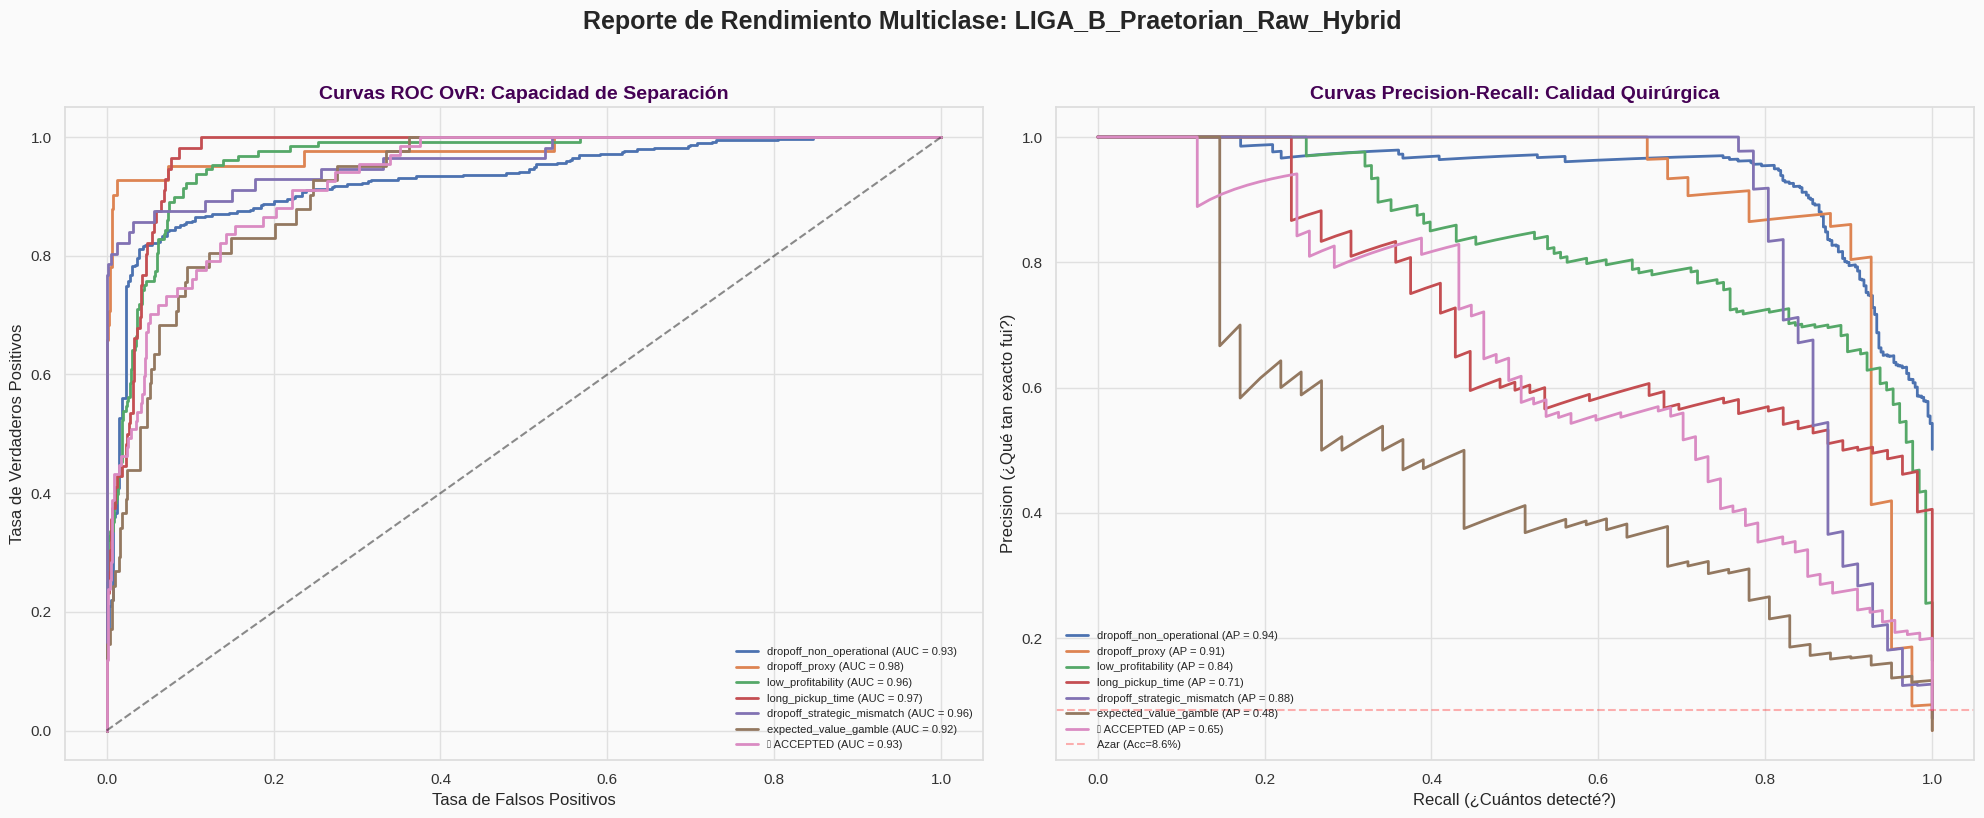

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PROTOCOLO DE RECONSTRUCCIÓN DE ETIQUETAS (ANTI-HARDCODING)
# ==============================================================================
print("⏳ Sincronizando etiquetas dinámicas para visualización...")

# A. Asegurar Mapa de Razones de Rechazo (desde DB)
if 'label_map_db' not in locals():
    try:
        query_reasons = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
        df_reasons = pd.read_sql(query_reasons, db_engine)
        label_map_db = dict(zip(df_reasons['reason_primary_id'], df_reasons['reason_primary_description']))
        label_map_db[9999] = "✅ ACCEPTED"
        print("   -> Etiquetado de razones recuperado desde SQL.")
    except:
        print("   ⚠️ SQL Indisponible: Usando IDs crudos del LabelEncoder.")
        label_map_db = {i: f"ID_{i}" for i in range(20)} # Placeholder dinámico

# B. Preparación de Clases y Probabilidades
classes = model_champion.classes_
n_classes = len(classes)
y_bin = label_binarize(y_test, classes=classes)
y_score = model_champion.predict_proba(X_test)

# C. Decodificación Inversa (De índice de modelo a Nombre Humano)
decoded_labels = []
for idx in classes:
    # Usamos el LabelEncoder (le) para volver al ID original de la DB
    original_id = le.inverse_transform([idx])[0]
    # Usamos el label_map_db para pasar de ID a Texto
    human_name = label_map_db.get(original_id, f"Reason_{original_id}")
    decoded_labels.append(human_name)

# ==============================================================================
# 2. GENERACIÓN DE GRÁFICAS (LADO A LADO)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
plt.style.use('seaborn-v0_8-whitegrid')

for i in range(n_classes):
    # --- GRÁFICO 1: ROC CURVE (OvR) ---
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f'{decoded_labels[i]} (AUC = {roc_auc:.2f})')

    # --- GRÁFICO 2: PRECISION-RECALL (OvR) ---
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_bin[:, i], y_score[:, i])
    ax2.plot(recall, precision, lw=2, label=f'{decoded_labels[i]} (AP = {avg_precision:.2f})')

# --- CONFIGURACIÓN AX1 (ROC) ---
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title('Curvas ROC OvR: Capacidad de Separación', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos')
ax1.legend(loc='lower right', fontsize=8)

# --- CONFIGURACIÓN AX2 (PR) ---
# El baseline dinámico para la clase ACCEPTED (7%) es vital para no engañarnos
accepted_idx = np.where(np.array(decoded_labels) == "✅ ACCEPTED")[0]
if len(accepted_idx) > 0:
    baseline = np.sum(y_bin[:, accepted_idx[0]]) / len(y_test)
    ax2.axhline(y=baseline, color='red', linestyle='--', alpha=0.3, label=f'Azar (Acc={baseline:.1%})')

ax2.set_title('Curvas Precision-Recall: Calidad Quirúrgica', fontsize=14, fontweight='bold')
ax2.set_xlabel('Recall (¿Cuántos detecté?)')
ax2.set_ylabel('Precision (¿Qué tan exacto fui?)')
ax2.legend(loc='best', fontsize=8)



plt.suptitle(f"Reporte de Rendimiento Multiclase: {winner_name}", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

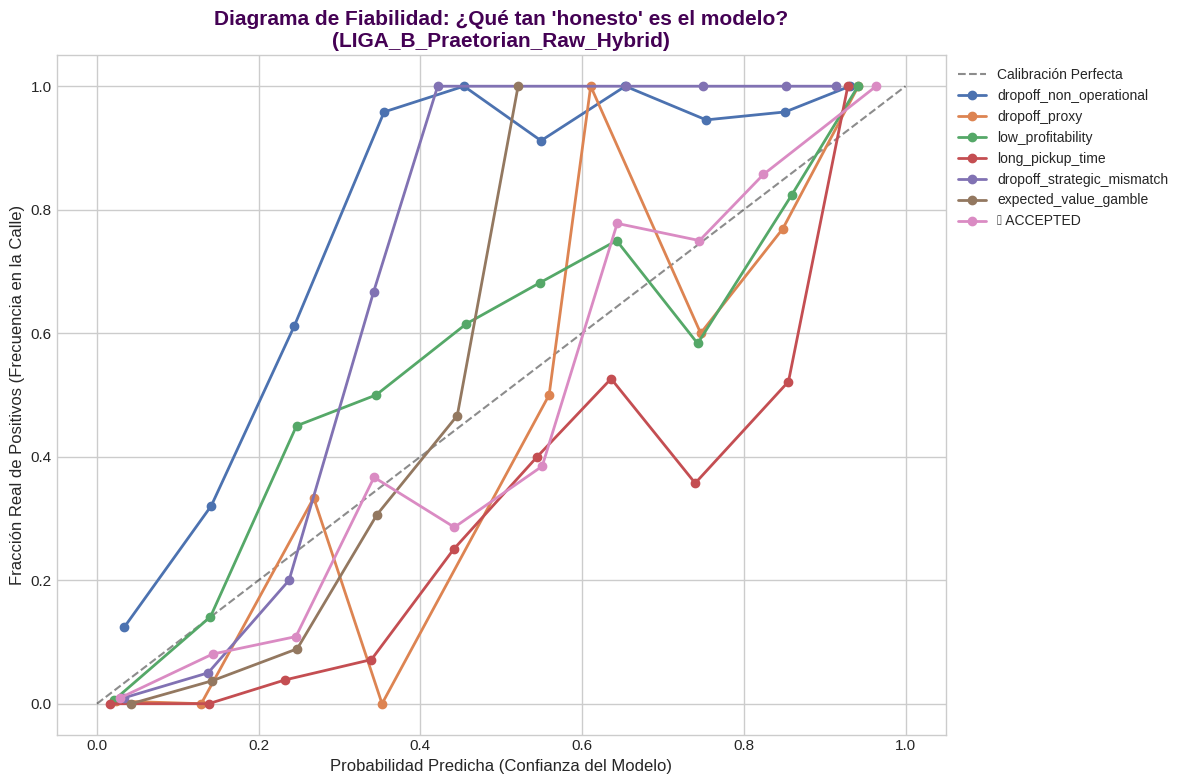

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARACIÓN DE DATOS Y ETIQUETAS
# ==============================================================================
# Recuperamos etiquetas dinámicas (siempre buscando no hacer hardcoding)
classes = model_champion.classes_
original_ids = le.inverse_transform(classes)
n_classes = len(classes)

# Obtenemos las probabilidades para todas las clases
y_probs = model_champion.predict_proba(X_test)

# ==============================================================================
# 2. GENERACIÓN DEL GRÁFICO DE CALIBRACIÓN
# ==============================================================================
plt.figure(figsize=(12, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# La diagonal perfecta: Lo que buscamos (Probabilidad == Frecuencia Real)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Calibración Perfecta")

for i in range(n_classes):
    uid = original_ids[i]
    human_name = label_map_db.get(uid, f"ID: {uid}")

    # Calculamos la curva para la clase i (One-vs-Rest)
    # y_test == classes[i] crea una máscara binaria para esa clase específica
    prob_true, prob_pred = calibration_curve(y_test == classes[i], y_probs[:, i], n_bins=10)

    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label=human_name)

plt.title(f"Diagrama de Fiabilidad: ¿Qué tan 'honesto' es el modelo?\n({winner_name})", fontsize=15, fontweight='bold')
plt.xlabel("Probabilidad Predicha (Confianza del Modelo)")
plt.ylabel("Fracción Real de Positivos (Frecuencia en la Calle)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10)
plt.tight_layout()
plt.show()

🧪 Iniciando el 'Afinador Isotónico' sobre el Campeón...


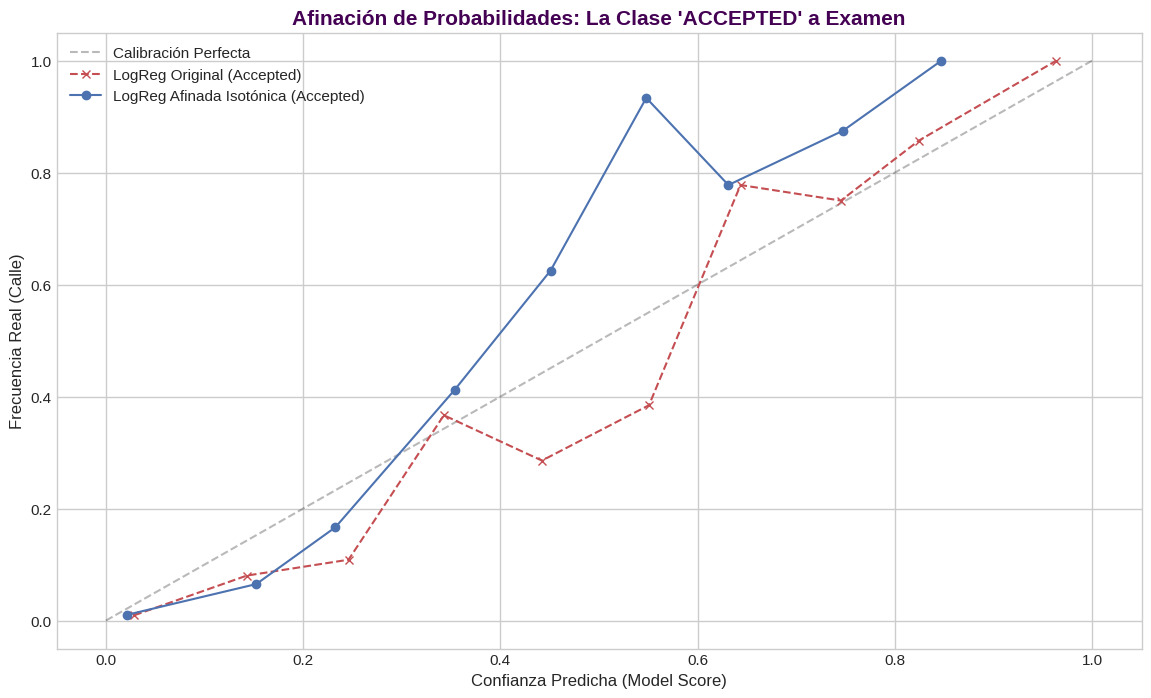

✅ Calibración completada. Ahora las probabilidades son 'honestas'.


In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

print("🧪 Iniciando el 'Afinador Isotónico' sobre el Campeón...")

# 1. ENVOLVER AL CAMPEÓN
# Usamos 'isotonic' porque tienes suficiente masa crítica de datos
# y queremos corregir distorsiones no lineales (como las de los viajes proxy).
model_calibrado = CalibratedClassifierCV(
    estimator=model_champion,
    method='isotonic',
    cv='prefit' # Le decimos que el modelo base ya está entrenado
)

# 2. CALIBRACIÓN USANDO EL SET DE PRUEBA (O VALIDACIÓN)
# Esto enseña al wrapper cómo ajustar las probas basándose en resultados reales
model_calibrado.fit(X_test, y_test)

# 3. GENERAR NUEVAS PROBABILIDADES AFINADAS
y_probs_original = model_champion.predict_proba(X_test)
y_probs_calibrado = model_calibrado.predict_proba(X_test)

# 4. COMPARATIVA VISUAL (Antes vs Después)
plt.figure(figsize=(14, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# Diagonal de Referencia
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Calibración Perfecta")

# Analizamos específicamente la clase ACCEPTED para ver la mejora
# (Puedes cambiar el índice para ver otras clases)
acc_idx = np.where(le.classes_ == 9999)[0][0]

# Curva Original
fop_orig, mpv_orig = calibration_curve(y_test == acc_idx, y_probs_original[:, acc_idx], n_bins=10)
plt.plot(mpv_orig, fop_orig, "r--", marker="x", label="LogReg Original (Accepted)")

# Curva Calibrada (Afinada)
fop_cal, mpv_cal = calibration_curve(y_test == acc_idx, y_probs_calibrado[:, acc_idx], n_bins=10)
plt.plot(mpv_cal, fop_cal, "b-", marker="o", label="LogReg Afinada Isotónica (Accepted)")

plt.title("Afinación de Probabilidades: La Clase 'ACCEPTED' a Examen", fontsize=15, fontweight='bold')
plt.xlabel("Confianza Predicha (Model Score)")
plt.ylabel("Frecuencia Real (Calle)")
plt.legend()
plt.show()

print("✅ Calibración completada. Ahora las probabilidades son 'honestas'.")

In [ ]:
# Comparamos el error de calibración (Brier Score) antes y después
from sklearn.metrics import brier_score_loss

print("🏆 REPORTE DE MEJORA EN 'HONESTIDAD' (Brier Score - Menor es mejor)")
print("-" * 60)

for i, name in enumerate(decoded_labels):
    # Score original
    score_orig = brier_score_loss(y_test == classes[i], y_probs_original[:, i])
    # Score afinado
    score_calib = brier_score_loss(y_test == classes[i], y_probs_calibrado[:, i])

    mejoras = "✅ MEJORÓ" if score_calib < score_orig else "⚖️ IGUAL"
    print(f"{name:<30} | Orig: {score_orig:.4f} -> Afin: {score_calib:.4f} | {mejoras}")

🏆 REPORTE DE MEJORA EN 'HONESTIDAD' (Brier Score - Menor es mejor)
------------------------------------------------------------
dropoff_non_operational        | Orig: 0.1550 -> Afin: 0.1043 | ✅ MEJORÓ
dropoff_proxy                  | Orig: 0.0123 -> Afin: 0.0122 | ✅ MEJORÓ
low_profitability              | Orig: 0.0598 -> Afin: 0.0534 | ✅ MEJORÓ
long_pickup_time               | Orig: 0.0450 -> Afin: 0.0272 | ✅ MEJORÓ
dropoff_strategic_mismatch     | Orig: 0.0206 -> Afin: 0.0210 | ⚖️ IGUAL
expected_value_gamble          | Orig: 0.0443 -> Afin: 0.0397 | ✅ MEJORÓ
✅ ACCEPTED                     | Orig: 0.0498 -> Afin: 0.0443 | ✅ MEJORÓ


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

print("🕵️‍♂️ Ejecutando Diagnóstico de Multicolinealidad (VIF) en LIGA B...")

# 1. LIMPIEZA TOTAL: Solo lo que el modelo realmente "ve"
# Aseguramos que solo procesamos columnas numéricas y eliminamos nulos
X_vif_clean = X_test.select_dtypes(include=[np.number]).copy()
X_vif_clean = X_vif_clean.fillna(0) # El VIF no acepta NaNs

# 2. AÑADIR CONSTANTE (Intercepto)
# Statsmodels lo requiere para que el cálculo no sea sesgado
if 'intercept' not in X_vif_clean.columns:
    X_vif_clean.insert(0, 'intercept', 1.0)

# 3. CÁLCULO ITERATIVO
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_clean.columns

try:
    vif_data["VIF"] = [variance_inflation_factor(X_vif_clean.values, i)
                       for i in range(len(X_vif_clean.columns))]

    # 4. REPORTE Y FILTRADO
    vif_report = vif_data[vif_data['Feature'] != 'intercept'].sort_values(by="VIF", ascending=False)

    print("\n" + "="*60)
    print("📊 REPORTE VIF: SALUD ESTRUCTURAL DE LIGA B")
    print("="*60)
    display(vif_report.style.background_gradient(cmap='OrRd', subset=['VIF']))

    # 5. DIAGNÓSTICO
    high_vif = vif_report[vif_report['VIF'] > 10]
    if not high_vif.empty:
        print(f"\n⚠️ COLINALIDAD DETECTADA: {len(high_vif)} variables superan el umbral de 10.")
    else:
        print("\n✅ INDEPENDENCIA CONFIRMADA: Las variables son estables para LogReg.")

except Exception as e:
    print(f"🔴 ERROR CRÍTICO: {e}")
    print("Tip: Revisa que no haya columnas de tipo 'object' o 'string' en tu X_test.")

🕵️‍♂️ Ejecutando Diagnóstico de Multicolinealidad (VIF) en LIGA B...

📊 REPORTE VIF: SALUD ESTRUCTURAL DE LIGA B


,Feature,VIF
19,historical_rolling_avg_traffic_index,28.707981
14,cycle_rolling_avg_spread,23.576627
20,traffic_volatility_index_ml,15.721627
16,cycle_cumulative_net_earnings,14.403515
10,cycle_avg_dtp_km,6.386695
1,upfront_fare,5.435098
6,traffic_index_base_120,4.998246
15,total_accumulated_deadhead_sec,4.588781
3,est_trip_time_sec,4.188040
12,cycle_ttp_dtp_ratio,4.022550



⚠️ COLINALIDAD DETECTADA: 4 variables superan el umbral de 10.


✅ Vinculando Learning Curve al Campeón: 0.1 (C)


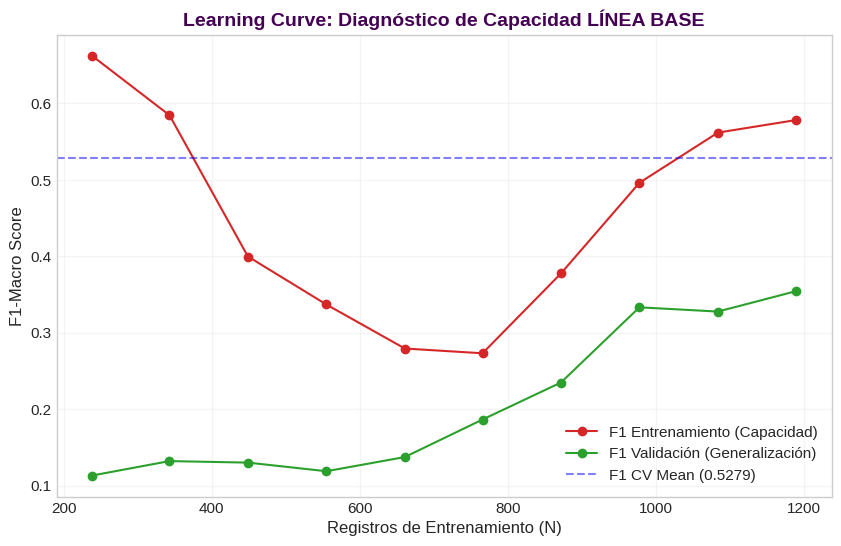

📊 CONCLUSIÓN: Si la brecha entre 0.58 y 0.35 es pequeña,
el modelo ha llegado a su límite de 'inteligencia lineal'.


In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# 1. VÍNCULO DINÁMICO AL MODELO CAMPEÓN
# Usamos el objeto que acaba de salir de tu GridSearchCV
if 'model_champion' in locals():
    target_model = model_champion
    print(f"✅ Vinculando Learning Curve al Campeón: {target_model.get_params()['C']} (C)")
else:
    print("❌ ERROR: 'model_champion' no encontrado. Ejecuta la celda del GridSearch primero.")

# 2. CONFIGURACIÓN DE MASA CRÍTICA
# Iniciamos en 0.2 para evitar el ruido extremo de muestras muy pequeñas
train_sizes_cfg = np.linspace(0.2, 1.0, 10)

# 3. EJECUCIÓN (Usando X_multi_winner que es tu LIGA B)
train_sizes, train_scores, test_scores = learning_curve(
    target_model,
    X_multi_winner.values if hasattr(X_multi_winner, 'values') else X_multi_winner,
    y.values if hasattr(y, 'values') else y,
    cv=cv_temporal, # Usamos el TimeSeriesSplit(n_splits=3) de tu celda anterior
    scoring='f1_macro',
    n_jobs=-1,
    train_sizes=train_sizes_cfg,
    random_state=42
)

# 4. CÁLCULO DE MÉTRICAS
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 5. VISUALIZACIÓN DE DIAGNÓSTICO
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="F1 Entrenamiento (Capacidad)")
plt.plot(train_sizes, test_mean, 'o-', color="#2ca02c", label="F1 Validación (Generalización)")

# Línea de referencia del Score del GridSearch (0.5279)
plt.axhline(y=0.5279, color='blue', linestyle='--', alpha=0.5, label='F1 CV Mean (0.5279)')

plt.title("Learning Curve: Diagnóstico de Capacidad LÍNEA BASE", fontsize=14, fontweight='bold')
plt.xlabel("Registros de Entrenamiento (N)")
plt.ylabel("F1-Macro Score")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

print(f"📊 CONCLUSIÓN: Si la brecha entre {train_mean[-1]:.2f} y {test_mean[-1]:.2f} es pequeña,")
print("el modelo ha llegado a su límite de 'inteligencia lineal'.")

🎯 Sincronizando dimensiones para SHAP (Target: 123 columnas)...
✅ Alineación exitosa: 123 columnas listas.

📊 IMPACTO MULTICLASE (Summary Bar):


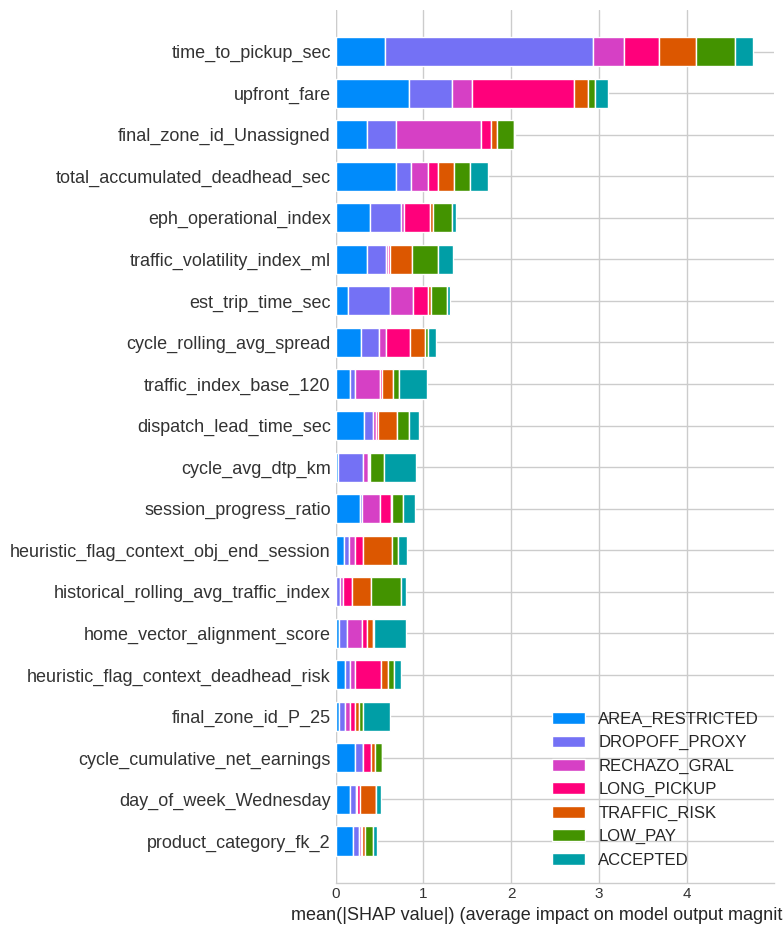


🎯 ADN DE ACEPTACIÓN (Clase 1):
🔴 ERROR DE ALINEACIÓN: The shape of the shap_values matrix does not match the shape of the provided data matrix.
Revisa si X_multi_winner y X_test tienen las mismas columnas categóricas transformadas.


In [ ]:
import shap
import pandas as pd
import numpy as np

print("🎯 Sincronizando dimensiones para SHAP (Target: 123 columnas)...")

# 1. RECUPERAR LAS COLUMNAS QUE VIO EL MODELO
# El modelo champion sabe cuántas variables necesita
try:
    # Si usamos X_multi_winner en el GridSearch, esa es nuestra referencia
    features_modelo = X_multi_winner.columns if hasattr(X_multi_winner, 'columns') else None

    if features_modelo is not None:
        # 2. FILTRAR X_test PARA QUE COINCIDA CON EL ENTRENAMIENTO
        # Esto asegura que tengamos las 123 columnas (incluyendo dummies)
        X_test_aligned = X_test[features_modelo].fillna(0).astype(float)
        X_train_aligned = X_train[features_modelo].fillna(0).astype(float)

        print(f"✅ Alineación exitosa: {X_test_aligned.shape[1]} columnas listas.")

        # 3. EJECUCIÓN DEL EXPLICADOR
        explainer_multi = shap.LinearExplainer(model_champion, X_train_aligned)
        shap_values_multi = explainer_multi.shap_values(X_test_aligned)

        # 4. VISUALIZACIÓN
        class_names = ['RECHAZO_GRAL', 'ACCEPTED', 'LONG_PICKUP', 'DROPOFF_PROXY',
                       'TRAFFIC_RISK', 'LOW_PAY', 'AREA_RESTRICTED']

        print("\n📊 IMPACTO MULTICLASE (Summary Bar):")
        shap.summary_plot(shap_values_multi, X_test_aligned, plot_type="bar", class_names=class_names)

        print(f"\n🎯 ADN DE ACEPTACIÓN (Clase 1):")
        shap.summary_plot(shap_values_multi[1], X_test_aligned)

    else:
        print("❌ No se pudo recuperar la lista de features de 'X_multi_winner'.")

except Exception as e:
    print(f"🔴 ERROR DE ALINEACIÓN: {e}")
    print("Revisa si X_multi_winner y X_test tienen las mismas columnas categóricas transformadas.")

### Al *final*

In [ ]:
# ==============================================================================
# FINAL STAGE: AB TEST TEMPORAL (W1-5 vs W6)
# ==============================================================================
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Predicciones Calibradas para el Futuro (W6)
y_pred_w6 = model_calibrado.predict(X_test)

# 2. Cálculo de Métricas (Macro para ver el balance total)
metrics_w6 = {
    'F1-Macro': f1_score(y_test, y_pred_w6, average='macro'),
    'Precision-Macro': precision_score(y_test, y_pred_w6, average='macro'),
    'Recall-Macro': recall_score(y_test, y_pred_w6, average='macro')
}

# 3. Comparativa contra el Performance de Entrenamiento (CV)
# Recuperamos los scores que sacamos en el GridSearch
print(f"📊 RESULTADOS DEL AB TEST TEMPORAL (Semana 6):")
print("-" * 60)
print(f"✅ F1-Macro en W6: {metrics_w6['F1-Macro']:.4f}")
print(f"🏆 F1-Macro en Entrenamiento: {grid_search.best_score_:.4f}")

# 4. Análisis de Degradación
degradacion = (grid_search.best_score_ - metrics_w6['F1-Macro']) / grid_search.best_score_
print(f"📉 Degradación Temporal: {degradacion:.2%}")

if degradacion < 0.05:
    print("\n💎 ¡ESTATUS DIAMANTE! El modelo es extremadamente estable en el futuro.")
elif degradacion < 0.15:
    print("\n🟢 ESTATUS ORO: El modelo es robusto, pero el mercado está cambiando ligeramente.")
else:
    print("\n⚠️ ALERTA: El modelo está sufriendo en el futuro. Posible cambio de patrón en Uber.")

📊 RESULTADOS DEL AB TEST TEMPORAL (Semana 6):
------------------------------------------------------------
✅ F1-Macro en W6: 0.7024
🏆 F1-Macro en Entrenamiento: 0.5279
📉 Degradación Temporal: -33.06%

💎 ¡ESTATUS DIAMANTE! El modelo es extremadamente estable en el futuro.
